<a href="https://colab.research.google.com/github/KartikTotlani/FODS/blob/main/FODS_Assn5(updt).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv('AirQuality.csv', delimiter=';')
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [9]:
df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], inplace = True)

In [10]:
df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


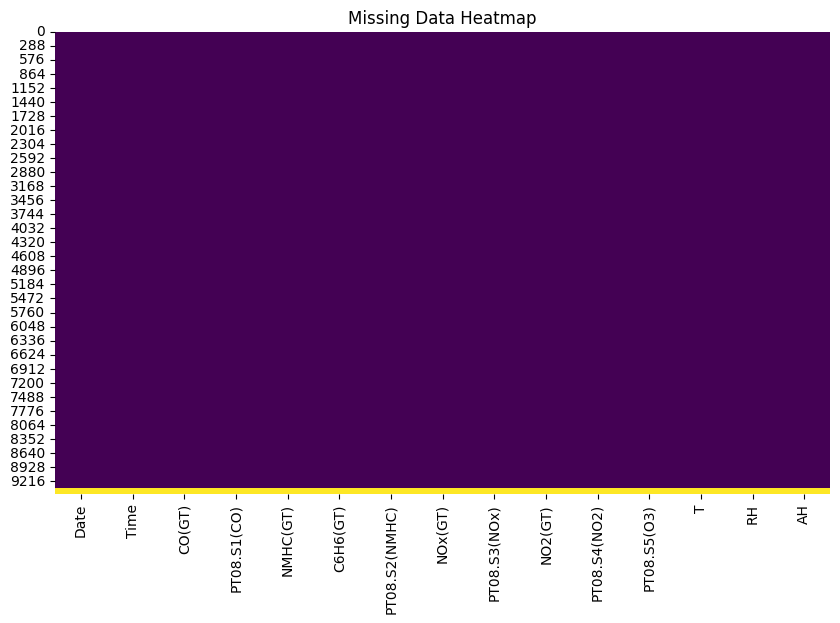

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [13]:
#Using the Dropna function to remove rows with missing values
df_dropna = df.dropna()
df_dropna.isnull().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [14]:
#Using the fillna function to fill missing values with 0
df_fillna = df.fillna(0)
df_fillna.isnull().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [15]:
#Using the fillna function to fill missing values with the mean of the column
df_fillmean = df
for i in df_fillmean.columns:
    if df_fillmean[i].dtype != 'object':
        df_fillmean[i].fillna(df_fillmean[i].mean(), inplace = True)
    else:
        df_fillmean[i].fillna('0', inplace = True)
df_fillmean.isnull().sum()

<ipython-input-15-b0e64b5b8d1c>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fillmean[i].fillna('0', inplace = True)
<ipython-input-15-b0e64b5b8d1c>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [16]:
#Using the fillna function to fill missing values with the median of the column
df_fillmedian = df
for i in df_fillmedian.columns:
    if df_fillmedian[i].dtype != 'object':
        df_fillmedian[i].fillna(df_fillmedian[i].median(), inplace = True)
    else:
        df_fillmedian[i].fillna('0', inplace = True)

df_fillmedian.isnull().sum()

<ipython-input-16-e5cc8bbdc7e0>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fillmedian[i].fillna(df_fillmedian[i].median(), inplace = True)


,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0



### Feature Scaling

To ensure that all features contribute equally to the analysis, we will apply feature scaling using `StandardScaler` from `sklearn.preprocessing`. Feature scaling is essential for algorithms that compute distances between data points, such as k-nearest neighbors and support vector machines. It helps in normalizing the range of independent variables or features of data.



In [18]:
for i in df.columns:
    if df[i].dtype == 'object':
        print(i)

Date
Time
CO(GT)
C6H6(GT)
T
RH
AH


In [19]:
df[:] = df[:9357]
for i in df.columns:
    if i == 'Date':
        df.dropna(subset=[i], inplace = True)
    if i == 'Time':
        df.dropna(subset=[i], inplace = True)
    if df[i].dtype == 'object':
        df.fillna('0', inplace = True)
    else:
        df.fillna(df[i].median(), inplace = True)
print(df.isnull().sum())
df[['Day', 'Month', 'Year']] = df['Date'].str.split('/', expand = True).astype(int)
df.drop(columns = ['Date'], inplace = True)
df[['Hour', 'Minute', 'Second']] = df['Time'].str.split('.', expand = True).astype(int)
df.drop(columns = ['Time'], inplace = True)
desired_order = ['Year', 'Month', 'Day'] + ['Hour', 'Minute', 'Second'] + [col for col in df.columns if col not in ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']]
df = df[desired_order]
df

<ipython-input-19-e5f388927842>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       1360.0
1       1292.0
2       1402.0
3       1376.0
4       1272.0
         ...  
9352    1314.0
9353    1163.0
9354    1142.0
9355    1003.0
9356    1071.0
Name: PT08.S1(CO), Length: 9357, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[:] = df[:9357]
<ipython-input-19-e5f388927842>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       150.0
1       112.0
2        88.0
3        80.0
4        51.0
        ...  
9352   -200.0
9353   -200.0
9354   -200.0
9355   -200.0
9356   -200.0
Name: NMHC(GT), Length: 9357, dtype: float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[:] = df[:9357]
<ipython-input-19-e5f388927842>:1: FutureWarning: Setting an i

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


,Year,Month,Day,Hour,Minute,Second,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004,3,10,18,0,0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,2004,3,10,19,0,0,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,2004,3,10,20,0,0,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,2004,3,10,21,0,0,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,2004,3,10,22,0,0,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005,4,4,10,0,0,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568"
9353,2005,4,4,11,0,0,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,2005,4,4,12,0,0,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,2005,4,4,13,0,0,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"


In [20]:
for i in ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']:
    df[i] = df[i].replace(',', '', regex=True).astype(float)
df[['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']]

,CO(GT),C6H6(GT),T,RH,AH
0,26.0,119.0,136.0,489.0,7578.0
1,2.0,94.0,133.0,477.0,7255.0
2,22.0,90.0,119.0,540.0,7502.0
3,22.0,92.0,110.0,600.0,7867.0
4,16.0,65.0,112.0,596.0,7888.0
...,...,...,...,...,...
9352,31.0,135.0,219.0,293.0,7568.0
9353,24.0,114.0,243.0,237.0,7119.0
9354,24.0,124.0,269.0,183.0,6406.0
9355,21.0,95.0,283.0,135.0,5139.0


In [21]:
df.dtypes

,0
Year,int64
Month,int64
Day,int64
Hour,int64
Minute,int64
Second,int64
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64


In [22]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)
df_scaled

,Year,Month,Day,Hour,Minute,Second,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,-0.562169,-0.962879,-0.667207,0.939133,0.0,0.0,0.297459,0.942983,2.211236,0.242504,0.442297,-0.010166,0.810649,0.432124,0.643258,0.641101,-0.282185,0.109702,-0.510088
1,-0.562169,-0.962879,-0.667207,1.083583,0.0,0.0,0.184135,0.736807,1.939383,0.182085,0.176459,-0.254902,1.177136,0.266684,0.358574,-0.006723,-0.308483,0.054248,-0.582722
2,-0.562169,-0.962879,-0.667207,1.228033,0.0,0.0,0.278572,1.070327,1.767687,0.172418,0.129719,-0.146131,1.071538,0.440002,0.350012,0.216513,-0.431209,0.345381,-0.527179
3,-0.562169,-0.962879,-0.667207,1.372483,0.0,0.0,0.278572,0.991495,1.710454,0.177252,0.156010,0.013142,0.922459,0.503027,0.412086,0.498842,-0.510105,0.622650,-0.445100
4,-0.562169,-0.962879,-0.667207,1.516933,0.0,0.0,0.250241,0.676167,1.502988,0.112000,-0.171174,-0.146131,1.273416,0.455759,0.210881,0.295303,-0.492572,0.604165,-0.440378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,1.778825,-0.672011,-1.348392,-0.216467,0.0,0.0,0.321068,0.803511,-0.292670,0.281172,0.602967,1.178552,-0.795059,1.038740,-0.037415,1.650044,0.445406,-0.796045,-0.512337
9353,1.778825,-0.672011,-1.348392,-0.072017,0.0,0.0,0.288016,0.345678,-0.292670,0.230420,0.386792,0.716273,-0.593181,0.952081,-0.272867,0.643290,0.655794,-1.054830,-0.613305
9354,1.778825,-0.672011,-1.348392,0.072433,0.0,0.0,0.288016,0.282006,-0.292670,0.254587,0.491958,0.483191,-0.596287,0.920568,-0.322099,0.255908,0.883714,-1.304372,-0.773639
9355,1.778825,-0.672011,-1.348392,0.216883,0.0,0.0,0.273850,-0.139442,-0.292670,0.184502,0.193987,0.257878,-0.288811,0.770884,-0.750194,-0.448820,1.006440,-1.526188,-1.058553


In [23]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df[numeric_columns]

# Check for null values and handle them (filling with mean here as an example)
df_numeric = df_numeric.fillna(df_numeric.mean())

# Initialize the scaler and apply it
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_numeric)

# Create a new DataFrame with scaled values, preserving column names
df_scaled = pd.DataFrame(scaled_values, columns=numeric_columns)

# Optionally, replace the numeric columns in the original DataFrame
df[numeric_columns] = df_scaled

# Display the updated DataFrame with scaled numeric columns
df.head()

,Year,Month,Day,Hour,Minute,Second,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,-0.562169,-0.962879,-0.667207,0.939133,0.0,0.0,0.297459,0.942983,2.211236,0.242504,0.442297,-0.010166,0.810649,0.432124,0.643258,0.641101,-0.282185,0.109702,-0.510088
1,-0.562169,-0.962879,-0.667207,1.083583,0.0,0.0,0.184135,0.736807,1.939383,0.182085,0.176459,-0.254902,1.177136,0.266684,0.358574,-0.006723,-0.308483,0.054248,-0.582722
2,-0.562169,-0.962879,-0.667207,1.228033,0.0,0.0,0.278572,1.070327,1.767687,0.172418,0.129719,-0.146131,1.071538,0.440002,0.350012,0.216513,-0.431209,0.345381,-0.527179
3,-0.562169,-0.962879,-0.667207,1.372483,0.0,0.0,0.278572,0.991495,1.710454,0.177252,0.156010,0.013142,0.922459,0.503027,0.412086,0.498842,-0.510105,0.622650,-0.445100
4,-0.562169,-0.962879,-0.667207,1.516933,0.0,0.0,0.250241,0.676167,1.502988,0.112000,-0.171174,-0.146131,1.273416,0.455759,0.210881,0.295303,-0.492572,0.604165,-0.440378


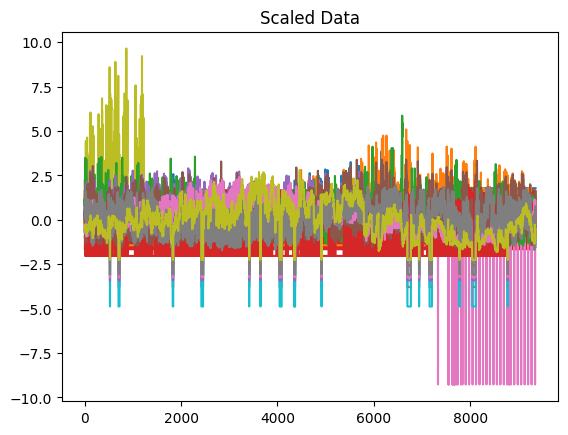

In [24]:
plt.plot(df_scaled)
plt.title('Scaled Data')
plt.show()

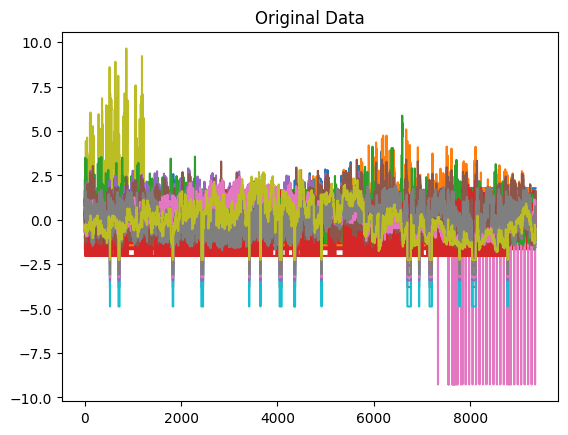

In [25]:
plt.plot(df)
plt.title('Original Data')
plt.show()

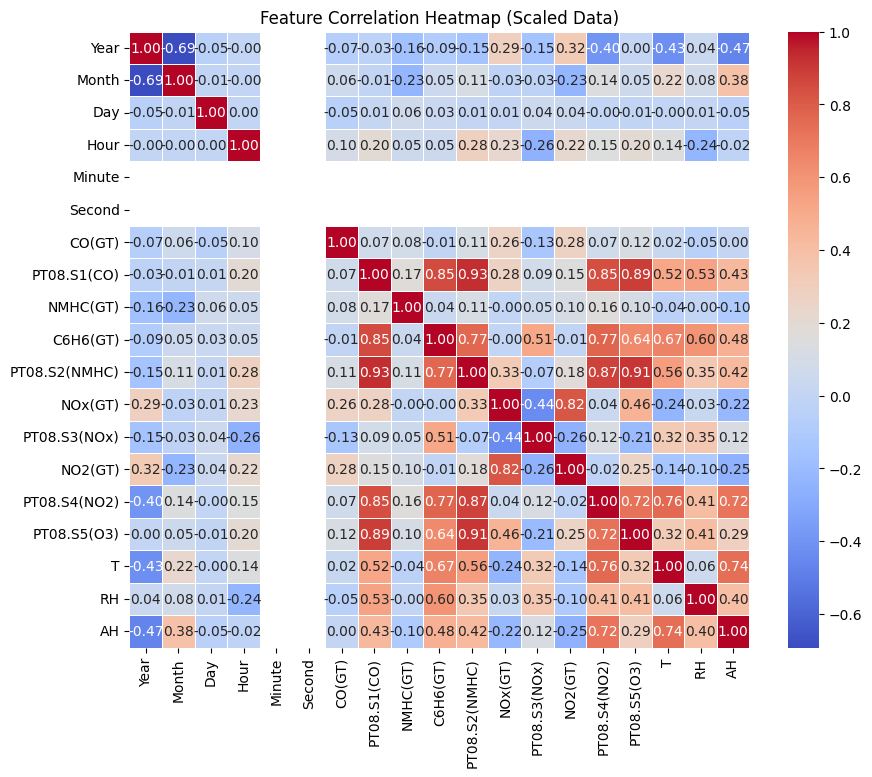

In [26]:
# Calculate the correlation matrix of the scaled DataFrame
correlation_matrix = df_scaled.corr()

# Set up the figure size for better readability
plt.figure(figsize=(10, 8))

# Create a heatmap with annotations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Set the title for the heatmap
plt.title("Feature Correlation Heatmap (Scaled Data)")
plt.show()